In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Cleaning**

In [5]:
print("Missing Values:", df.isnull().sum())

Missing Values: customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [7]:
print("Missing Values:", df.isnull().sum())

Missing Values: customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [8]:
df['TotalCharges'].fillna(0, inplace = True)

/tmp/ipykernel_2070/2215596053.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace = True)


In [9]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [10]:
df.drop(columns=['customerID'], inplace=True)

In [11]:
print("\nCleaned Dataset Shape:", df.shape)
print("\nMissing Values After Cleaning:", df.isnull().sum().sum())
df.head()


Cleaned Dataset Shape: (7043, 20)

Missing Values After Cleaning: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


**Feature Engineering**

In [12]:
def tenure_group(tenure):
    if tenure <= 12:
        return '0-12 Months'
    elif tenure <= 24:
        return '13-24 Months'
    elif tenure <= 48:
        return '25-48 Months'
    else:
        return '49+ Months'

df['TenureGroup'] = df['tenure'].apply(tenure_group)

In [13]:
df['ChargeGroup'] = pd.cut(df['MonthlyCharges'],
                           bins=[0, 30, 60, 90, 120],
                           labels=['Low (<$30)', 'Medium ($30-60)',
                                   'High ($60-90)', 'Very High (>$90)'])

In [14]:
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

In [15]:
df_services = df[service_cols].replace({'No internet service': 'No',
                                        'No phone service': 'No'})
df['NumServices'] = (df_services == 'Yes').sum(axis=1)

In [16]:
def risk_flag(row):
    score = 0
    if row['Contract'] == 'Month-to-month': score += 2
    if row['InternetService'] == 'Fiber optic': score += 1
    if row['PaymentMethod'] == 'Electronic check': score += 1
    if row['tenure'] <= 12: score += 1
    if score >= 4:
        return 'High Risk'
    elif score >= 2:
        return 'Medium Risk'
    else:
        return 'Low Risk'

In [17]:
df['RiskSegment'] = df.apply(risk_flag, axis=1)

In [18]:
print("New columns added:")
print(df[['TenureGroup', 'ChargeGroup', 'NumServices', 'RiskSegment']].head(10))

New columns added:
    TenureGroup       ChargeGroup  NumServices  RiskSegment
0   0-12 Months        Low (<$30)            1    High Risk
1  25-48 Months   Medium ($30-60)            3     Low Risk
2   0-12 Months   Medium ($30-60)            3  Medium Risk
3  25-48 Months   Medium ($30-60)            3     Low Risk
4   0-12 Months     High ($60-90)            1    High Risk
5   0-12 Months  Very High (>$90)            5    High Risk
6  13-24 Months     High ($60-90)            4  Medium Risk
7   0-12 Months        Low (<$30)            1  Medium Risk
8  25-48 Months  Very High (>$90)            6    High Risk
9    49+ Months   Medium ($30-60)            3     Low Risk


**EDA**

/tmp/ipykernel_2070/4104278347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['#42A5F5', '#EF5350'])


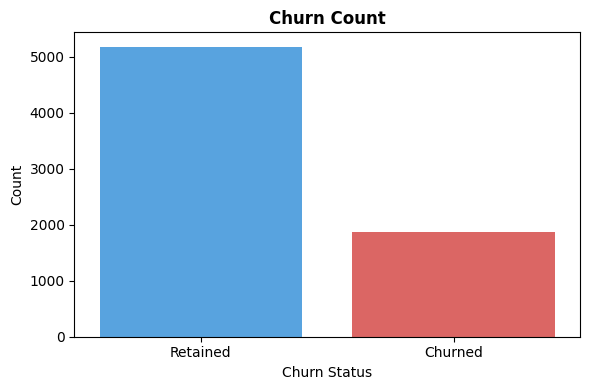

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette=['#42A5F5', '#EF5350'])
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.title('Churn Count', fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

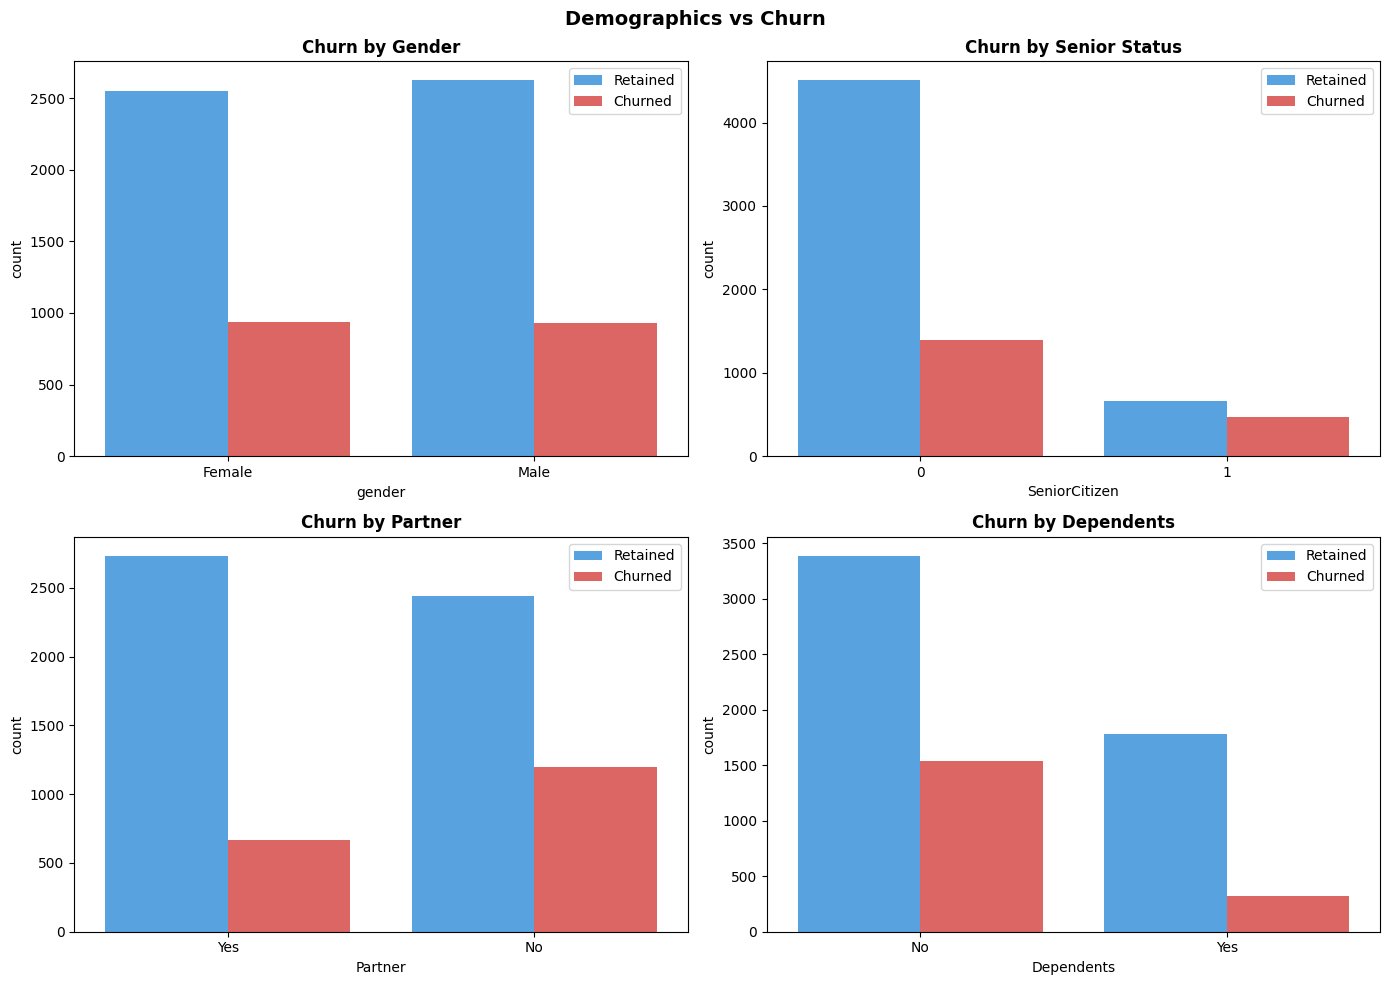

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='gender', hue='Churn', data=df,
              palette=['#42A5F5', '#EF5350'], ax=axes[0][0])
axes[0][0].set_title('Churn by Gender', fontweight='bold')
axes[0][0].legend(labels=['Retained', 'Churned'])

sns.countplot(x='SeniorCitizen', hue='Churn', data=df,
              palette=['#42A5F5', '#EF5350'], ax=axes[0][1])
axes[0][1].set_title('Churn by Senior Status', fontweight='bold')
axes[0][1].legend(labels=['Retained', 'Churned'])

sns.countplot(x='Partner', hue='Churn', data=df,
              palette=['#42A5F5', '#EF5350'], ax=axes[1][0])
axes[1][0].set_title('Churn by Partner', fontweight='bold')
axes[1][0].legend(labels=['Retained', 'Churned'])

sns.countplot(x='Dependents', hue='Churn', data=df,
              palette=['#42A5F5', '#EF5350'], ax=axes[1][1])
axes[1][1].set_title('Churn by Dependents', fontweight='bold')
axes[1][1].legend(labels=['Retained', 'Churned'])

plt.suptitle('Demographics vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

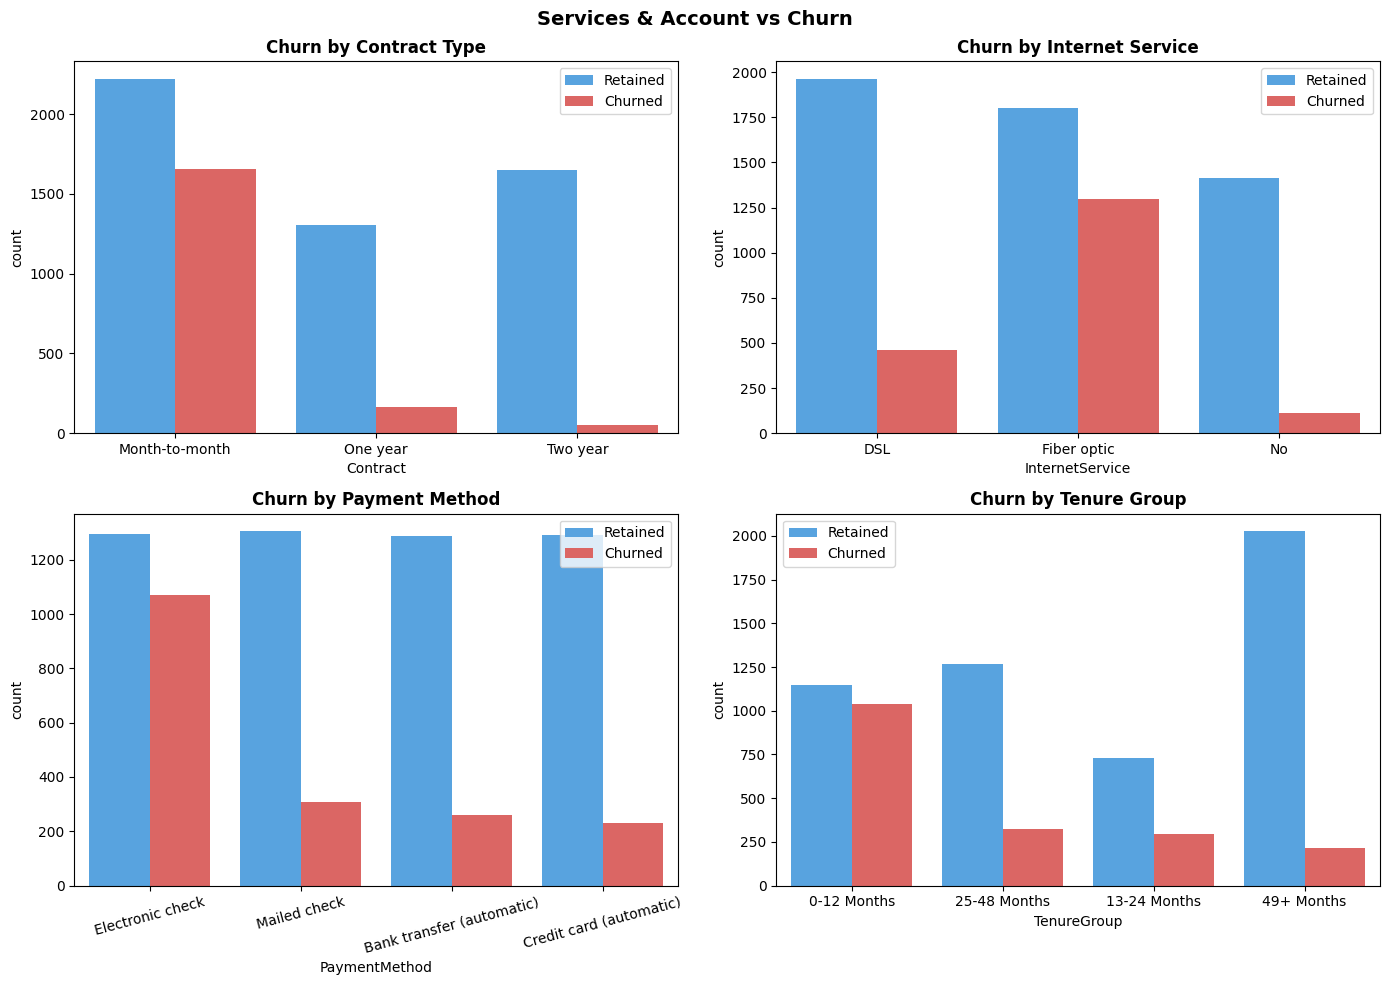

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='Contract', hue='Churn', data=df,
              palette=['#42A5F5', '#EF5350'], ax=axes[0][0])
axes[0][0].set_title('Churn by Contract Type', fontweight='bold')
axes[0][0].legend(labels=['Retained', 'Churned'])

sns.countplot(x='InternetService', hue='Churn', data=df,
              palette=['#42A5F5', '#EF5350'], ax=axes[0][1])
axes[0][1].set_title('Churn by Internet Service', fontweight='bold')
axes[0][1].legend(labels=['Retained', 'Churned'])

sns.countplot(x='PaymentMethod', hue='Churn', data=df,
              palette=['#42A5F5', '#EF5350'], ax=axes[1][0])
axes[1][0].set_title('Churn by Payment Method', fontweight='bold')
axes[1][0].tick_params(axis='x', rotation=15)
axes[1][0].legend(labels=['Retained', 'Churned'])

sns.countplot(x='TenureGroup', hue='Churn', data=df,
              palette=['#42A5F5', '#EF5350'], ax=axes[1][1])
axes[1][1].set_title('Churn by Tenure Group', fontweight='bold')
axes[1][1].legend(labels=['Retained', 'Churned'])

plt.suptitle('Services & Account vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

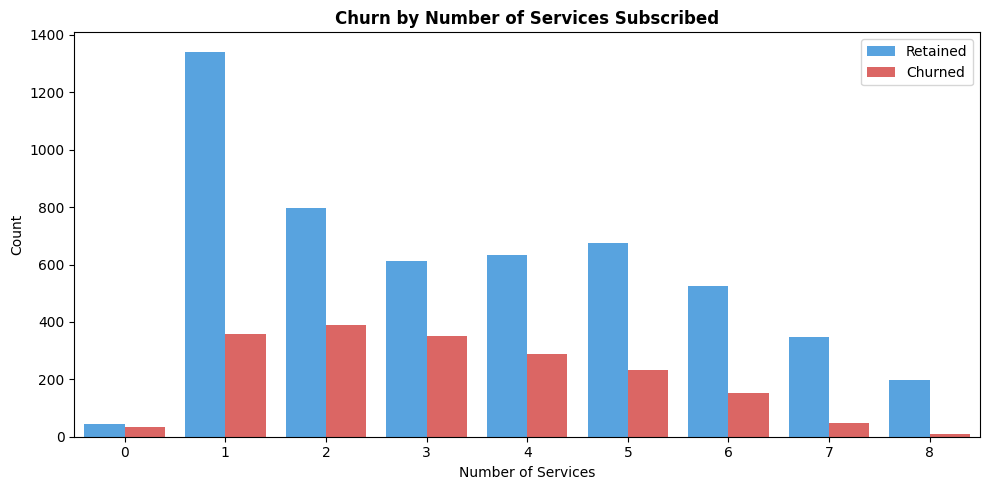

In [22]:
plt.figure(figsize=(10, 5))
sns.countplot(x='NumServices', hue='Churn', data=df,
              palette=['#42A5F5', '#EF5350'])
plt.title('Churn by Number of Services Subscribed', fontweight='bold')
plt.xlabel('Number of Services')
plt.ylabel('Count')
plt.legend(labels=['Retained', 'Churned'])
plt.tight_layout()
plt.show()

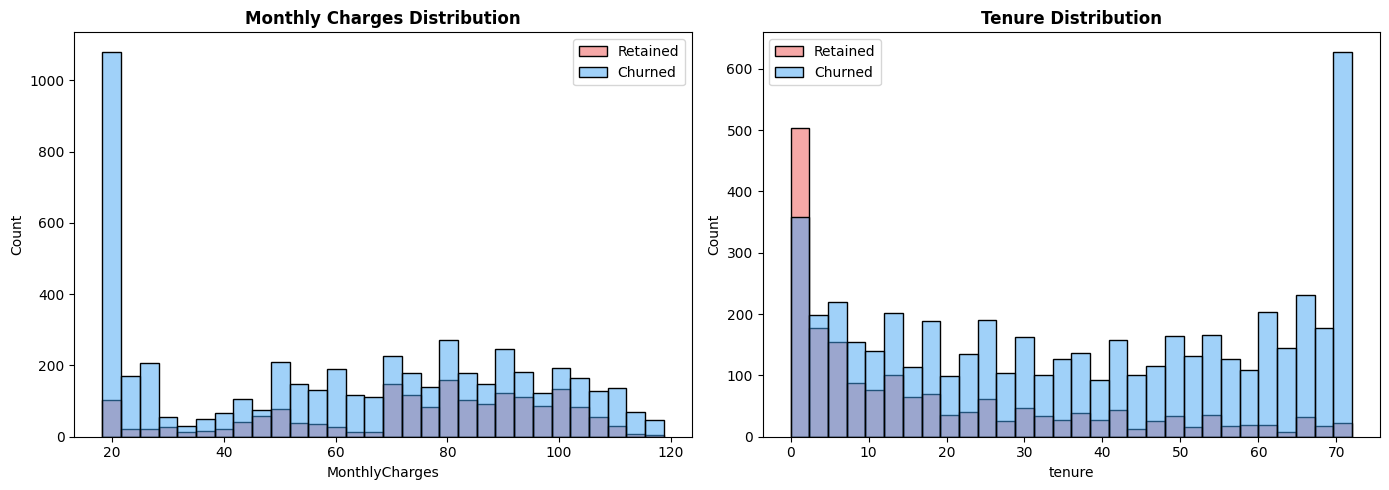

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='MonthlyCharges', hue='Churn',
             palette=['#42A5F5', '#EF5350'], bins=30, ax=axes[0])
axes[0].set_title('Monthly Charges Distribution', fontweight='bold')
axes[0].legend(labels=['Retained', 'Churned'])

sns.histplot(data=df, x='tenure', hue='Churn',
             palette=['#42A5F5', '#EF5350'], bins=30, ax=axes[1])
axes[1].set_title('Tenure Distribution', fontweight='bold')
axes[1].legend(labels=['Retained', 'Churned'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_2070/1749990255.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
/tmp/ipykernel_2070/1749990255.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Retained', 'Churned'])
/tmp/ipykernel_2070/1749990255.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df,
/tmp/ipykernel_2070/1749990255.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Retained', 'Churned'])
/tmp/ipykernel_2070/1749990

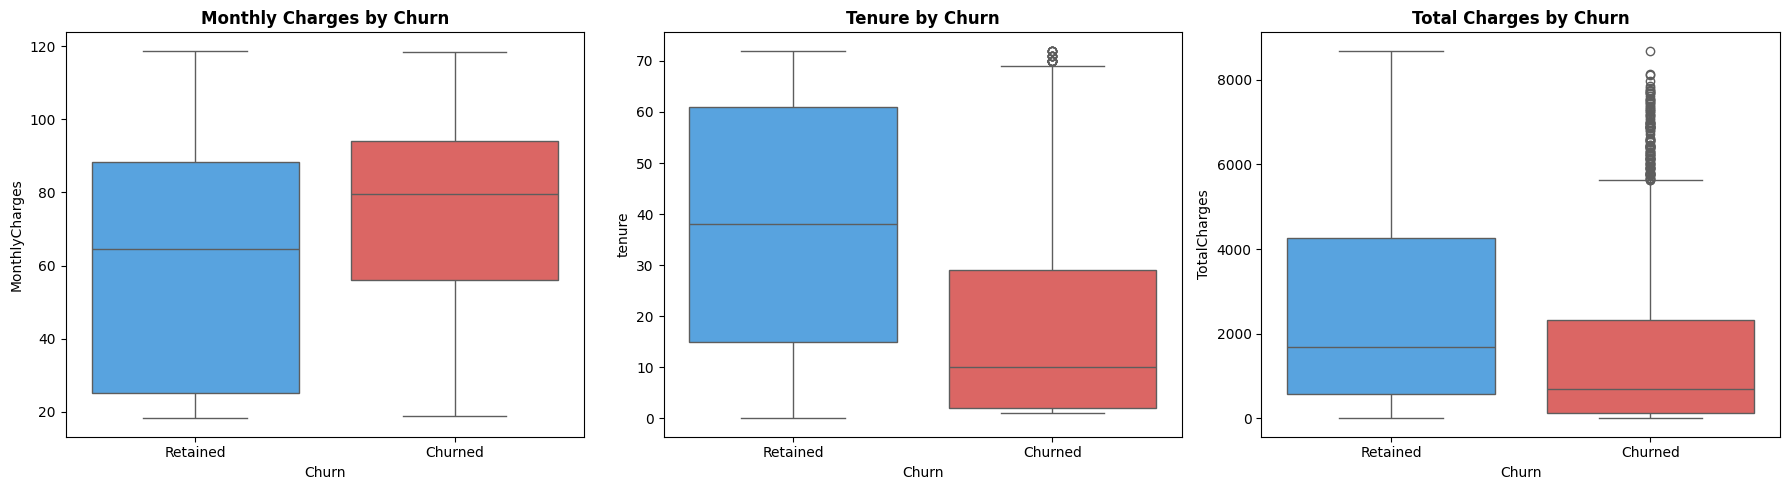

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            palette=['#42A5F5', '#EF5350'], ax=axes[0])
axes[0].set_xticklabels(['Retained', 'Churned'])
axes[0].set_title('Monthly Charges by Churn', fontweight='bold')

sns.boxplot(x='Churn', y='tenure', data=df,
            palette=['#42A5F5', '#EF5350'], ax=axes[1])
axes[1].set_xticklabels(['Retained', 'Churned'])
axes[1].set_title('Tenure by Churn', fontweight='bold')

sns.boxplot(x='Churn', y='TotalCharges', data=df,
            palette=['#42A5F5', '#EF5350'], ax=axes[2])
axes[2].set_xticklabels(['Retained', 'Churned'])
axes[2].set_title('Total Charges by Churn', fontweight='bold')

plt.tight_layout()
plt.show()

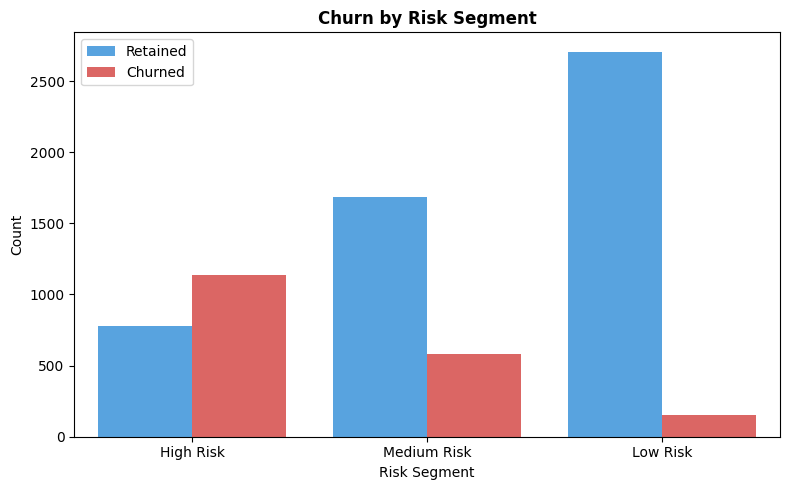

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(x='RiskSegment', hue='Churn', data=df,
              order=['High Risk', 'Medium Risk', 'Low Risk'],
              palette=['#42A5F5', '#EF5350'])
plt.title('Churn by Risk Segment', fontweight='bold')
plt.xlabel('Risk Segment')
plt.ylabel('Count')
plt.legend(labels=['Retained', 'Churned'])
plt.tight_layout()
plt.show()

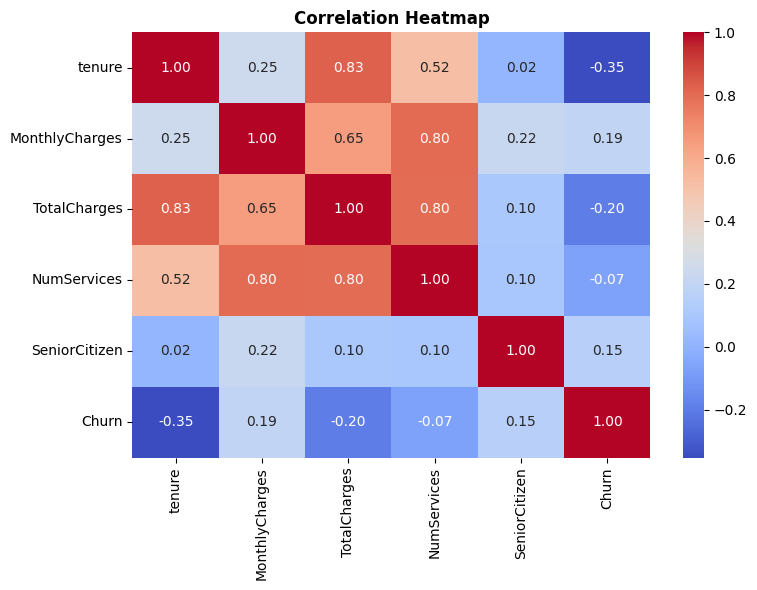

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges','NumServices', 'SeniorCitizen', 'Churn']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

**Preprocessing**

In [27]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

model_df = df.drop(columns=['SeniorCitizen', 'TenureGroup', 'ChargeGroup', 'RiskSegment'])

le = LabelEncoder()
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
            'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    model_df[col] = le.fit_transform(model_df[col].astype(str))

model_df = pd.get_dummies(model_df, columns=['gender', 'InternetService',
                                              'Contract', 'PaymentMethod'], drop_first=True)

X = model_df.drop(columns=['Churn'])
y = model_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Churn rate in Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%")

Train: 5634 | Test: 1409
Churn rate in Train: 26.5% | Test: 26.5%


**Model Building**

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
from xgboost import XGBClassifier

In [29]:
from sklearn.preprocessing import StandardScaler

# Scale the data — Logistic Regression converges much faster on scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Now train with scaled data
lr = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

print("LOGISTIC REGRESSION")
print(f"Accuracy : {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, lr_prob):.4f}")
print(classification_report(y_test, lr_pred, target_names=['Retained', 'Churned']))

LOGISTIC REGRESSION
Accuracy : 73.39%
ROC-AUC  : 0.8403
              precision    recall  f1-score   support

    Retained       0.90      0.72      0.80      1035
     Churned       0.50      0.78      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.75      1409



In [30]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                             min_samples_leaf=5, random_state=42,
                             class_weight='balanced')
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("RANDOM FOREST")
print(f"Accuracy : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_prob):.4f}")
print(classification_report(y_test, rf_pred, target_names=['Retained', 'Churned']))

RANDOM FOREST
Accuracy : 76.44%
ROC-AUC  : 0.8424
              precision    recall  f1-score   support

    Retained       0.90      0.77      0.83      1035
     Churned       0.54      0.75      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [31]:
xgb = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                    eval_metric='logloss', random_state=42,
                    scale_pos_weight=2.77)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

print("XGBOOST")
print(f"Accuracy : {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, xgb_prob):.4f}")
print(classification_report(y_test, xgb_pred, target_names=['Retained', 'Churned']))

XGBOOST
Accuracy : 75.23%
ROC-AUC  : 0.8416
              precision    recall  f1-score   support

    Retained       0.91      0.73      0.81      1035
     Churned       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



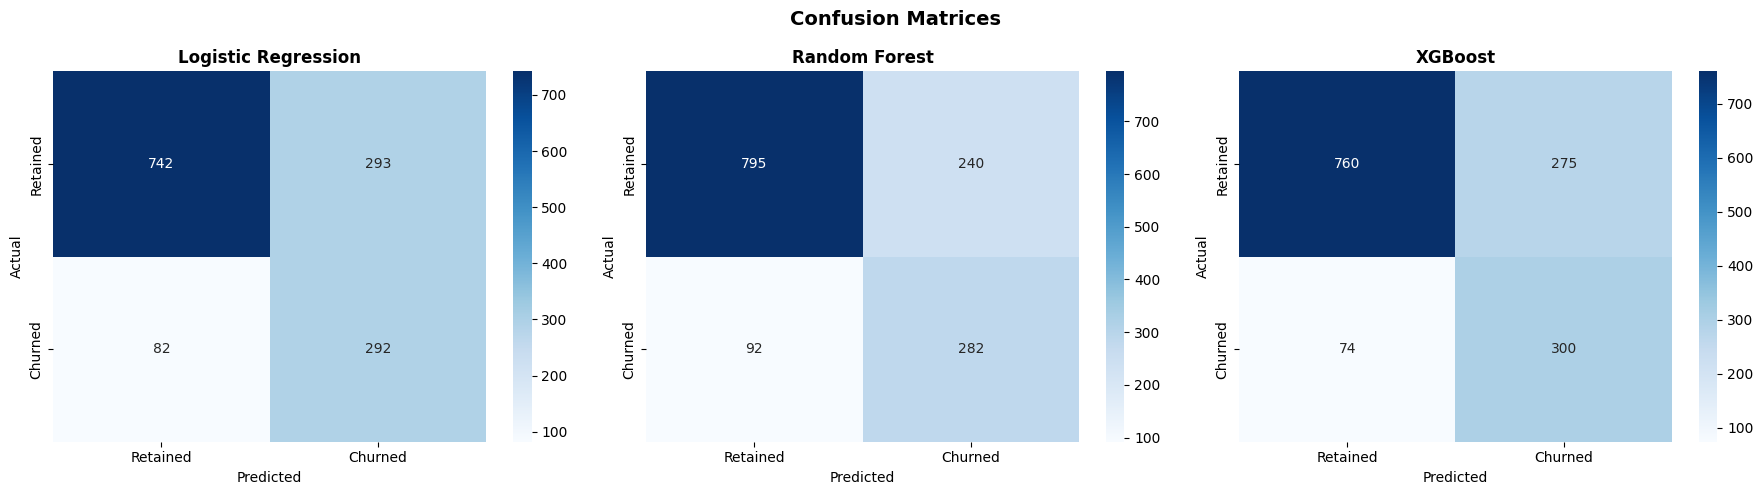

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, [('Logistic Regression', lr_pred),
                                     ('Random Forest', rf_pred),
                                     ('XGBoost', xgb_pred)]):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'])
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

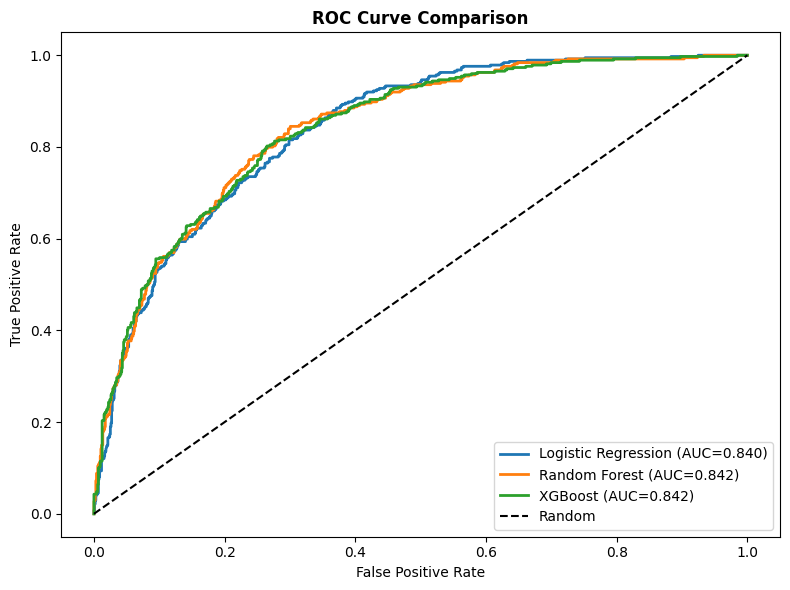

In [33]:
plt.figure(figsize=(8, 6))

for name, prob in [('Logistic Regression', lr_prob),
                   ('Random Forest', rf_prob),
                   ('XGBoost', xgb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, prob):.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
export_df = df.copy()
export_df['Churn_Probability'] = xgb.predict_proba(X)[:, 1].round(4)
export_df['Churn_Prediction']  = xgb.predict(X)
export_df['Churn_Risk_Score']  = (xgb.predict_proba(X)[:, 1] * 100).round(1)
export_df['Churn_Label']       = df['Churn'].map({1: 'Churned', 0: 'Retained'})

export_df.to_csv('churn_dashboard_data.csv', index=False)
print("✅ Exported: churn_dashboard_data.csv")
export_df[['gender', 'tenure', 'Contract', 'MonthlyCharges',
           'Churn_Label', 'Churn_Probability', 'RiskSegment']].head(10)

✅ Exported: churn_dashboard_data.csv


,gender,tenure,Contract,MonthlyCharges,Churn_Label,Churn_Probability,RiskSegment
0,Female,1,Month-to-month,29.85,Retained,0.8552,High Risk
1,Male,34,One year,56.95,Retained,0.0901,Low Risk
2,Male,2,Month-to-month,53.85,Churned,0.5553,Medium Risk
3,Male,45,One year,42.30,Retained,0.0687,Low Risk
4,Female,2,Month-to-month,70.70,Churned,0.8263,High Risk
5,Female,8,Month-to-month,99.65,Churned,0.9611,High Risk
6,Male,22,Month-to-month,89.10,Retained,0.6408,Medium Risk
7,Female,10,Month-to-month,29.75,Retained,0.3853,Medium Risk
8,Female,28,Month-to-month,104.80,Churned,0.8276,High Risk
9,Male,62,One year,56.15,Retained,0.0598,Low Risk
